<div style="background:#12355b;color:white;padding:16px 36px;border-radius:6px;">
<h1 style="margin:0;">Lab 03 - Exploratory Data Analysis</h1>
<p style="margin:6px 0 0;">Stack Overflow Developer Survey 2025</p>
</div>

## **Table of contents**

* [0. Setup & Imports](#0-setup-imports)
* [1. Load Processed Data](#1-load-processed-data)
* [2. Developer Demographics & Work Profile](#2-developer-demographics--work-profile)
* [3. Compensation & Job Satisfaction](#3-compensation--job-satisfaction)
* [4. Technology Ecosystem & Popularity](#4-technology-ecosystem--popularity)
* [5. AI Adoption, Sentiment & Trust](#5-ai-adoption-sentiment--trust)
* [6. Stack Overflow Community Dynamics](#6-stack-overflow-community-dynamics)
* [7. Cross-Dimension Correlations](#7-cross-dimension-correlations)
* [8. Key Findings & Strategic Insights](#8-key-findings--strategic-insights)

<a id="0-setup-imports"></a>
## **0. Setup & Imports**

**Mục tiêu:** Thiết lập môi trường làm việc, nạp các thư viện cần thiết cho phân tích số liệu và trực quan hóa dữ liệu, đồng thời cấu hình các thông số đồ họa đồng bộ để đảm bảo chất lượng hình ảnh hiển thị.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Set plotting configurations
plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
})
sns.set_theme(style='whitegrid')

# Define global visualization constants
PRIMARY_COLOR = '#1f77b4'
ACCENT_COLOR = '#e94560'
MUTED_COLOR = '#7f7f7f'

# Directory path configuration
PROCESSED_DIR = Path('../data/processed')
RAW_DIR = Path('../data/raw')

print('System environment initialized successfully.')

System environment initialized successfully.


<a id="1-load-processed-data"></a>
## **1. Load Processed Data**

**Mục tiêu:** Nạp dữ liệu chính từ bảng fact và các bảng chiều đã được chuẩn hóa ở bước tiền xử lý để phục vụ cho các phân tích khám phá tiếp theo.

In [101]:
# Load main datasets
fact_df = pd.read_csv(PROCESSED_DIR / 'fact_respondents.csv', encoding='utf-8-sig')
country_df = pd.read_csv(PROCESSED_DIR / 'dim_country.csv', encoding='utf-8-sig')
education_df = pd.read_csv(PROCESSED_DIR / 'dim_education.csv', encoding='utf-8-sig')
remote_df = pd.read_csv(PROCESSED_DIR / 'dim_remote_work.csv', encoding='utf-8-sig')
org_size_df = pd.read_csv(PROCESSED_DIR / 'dim_org_size.csv', encoding='utf-8-sig')
job_sat_df = pd.read_csv(PROCESSED_DIR / 'dim_job_satisfaction.csv', encoding='utf-8-sig')
ai_select_df = pd.read_csv(PROCESSED_DIR / 'dim_ai_select.csv', encoding='utf-8-sig')
ai_sent_df = pd.read_csv(PROCESSED_DIR / 'dim_ai_sentiment.csv', encoding='utf-8-sig')
ai_acc_df = pd.read_csv(PROCESSED_DIR / 'dim_ai_acc.csv', encoding='utf-8-sig')
ai_frust_dim = pd.read_csv(PROCESSED_DIR / 'dim_ai_frustration.csv', encoding='utf-8-sig')
ai_human_dim = pd.read_csv(PROCESSED_DIR / 'dim_ai_human.csv', encoding='utf-8-sig')
tech_dim = pd.read_csv(PROCESSED_DIR / 'dim_technology.csv', encoding='utf-8-sig')

# Load bridge tables
tech_bridge = pd.read_csv(PROCESSED_DIR / 'bridge_technology.csv', encoding='utf-8-sig')
ai_frust_bridge = pd.read_csv(PROCESSED_DIR / 'bridge_ai_frustration.csv', encoding='utf-8-sig')
ai_human_bridge = pd.read_csv(PROCESSED_DIR / 'bridge_ai_human.csv', encoding='utf-8-sig')

print('Processed datasets loaded successfully.')
print(f'Fact table records count: {len(fact_df):,}')

Processed datasets loaded successfully.
Fact table records count: 49,191


**Nhận xét:**
Bảng fact chứa thông tin của 49.191 lập trình viên tham gia khảo sát. Các bảng chiều và bảng liên kết đi kèm đã được chuẩn hóa đầy đủ cấu trúc dữ liệu, sẵn sàng cho quá trình phân tích.

<a id="2-developer-demographics--work-profile"></a>
## **2. Developer Demographics & Work Profile**

**Mục tiêu:** Phân tích các yếu tố nhân khẩu học chính bao gồm phân bố quốc gia của lập trình viên, trình độ học vấn và xu hướng lựa chọn hình thức làm việc.

<a id="21-top-countries-by-respondents"></a>
### **2.1. Top Countries by Respondents**

**Câu hỏi:** Những quốc gia nào đóng góp nhiều phản hồi nhất trong cuộc khảo sát năm 2025?

**Phương pháp:** Tính tần suất xuất hiện của mã quốc gia trong bảng fact, kết nối với bảng chiều quốc gia và trực quan hóa top 10 bằng biểu đồ cột đứng.

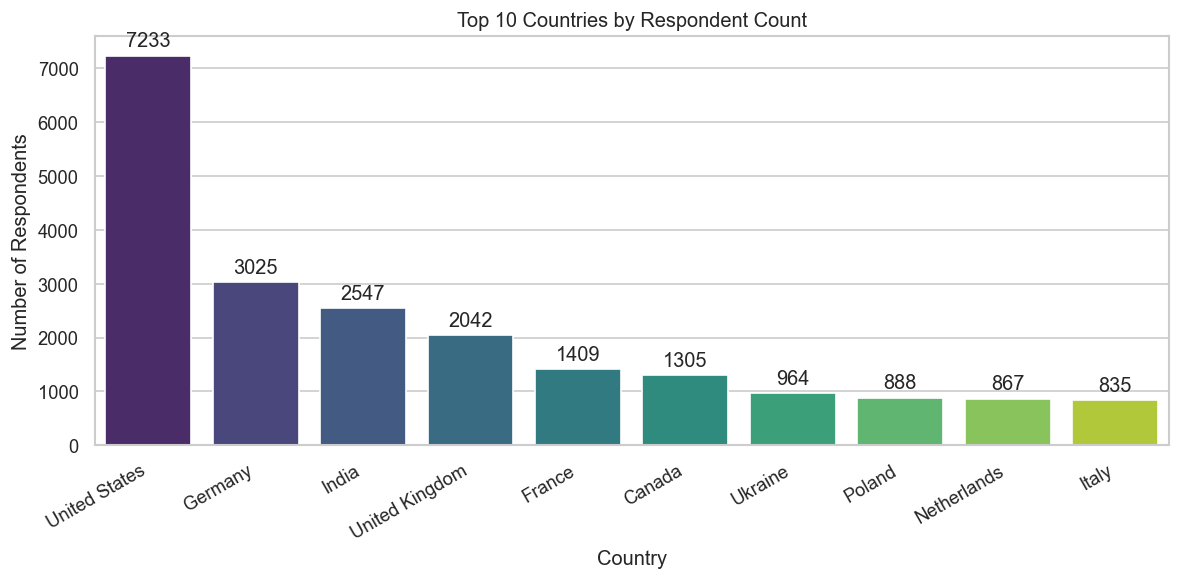

In [102]:
# Top 10 Countries by respondent count (excluding Unknown) (Vertical Bar Chart)
top_countries = (
    fact_df['CountryId'].value_counts().reset_index()
    .merge(country_df, on='CountryId')
)
top_countries = top_countries[top_countries['Country'] != 'Unknown'].head(10)

# Shorten country names if necessary
country_name_map = {
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United States of America': 'United States'
}
top_countries['Country'] = top_countries['Country'].replace(country_name_map)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='Country', y='count', data=top_countries, palette='viridis', hue='Country', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title('Top 10 Countries by Respondent Count')
plt.xlabel('Country')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Hoa Kỳ (United States) là quốc gia có lượng phản hồi cao nhất trong số các quốc gia đã xác định với 7.233 người (khoảng 14.7%), theo sau là Đức với 3.025 người (6.15%) và Ấn Độ với 2.547 người (5.18%).
* Các quốc gia châu Âu phát triển như Vương quốc Anh (2.042 người), Pháp (1.409 người) và Ba Lan (888 người) cũng đóng góp lượng phản hồi đáng kể trong cuộc khảo sát năm nay.

<a id="22-education-level-distribution"></a>
### **2.2. Education Level Distribution**

**Câu hỏi:** Trình độ học vấn phổ biến nhất của các lập trình viên tham gia khảo sát là gì?

**Phương pháp:** Tính toán phân bố tần suất của các nhóm trình độ học vấn trong bảng fact, kết nối với bảng chiều trình độ học vấn và vẽ biểu đồ cột dọc để quan sát trực quan quy mô phân bố.

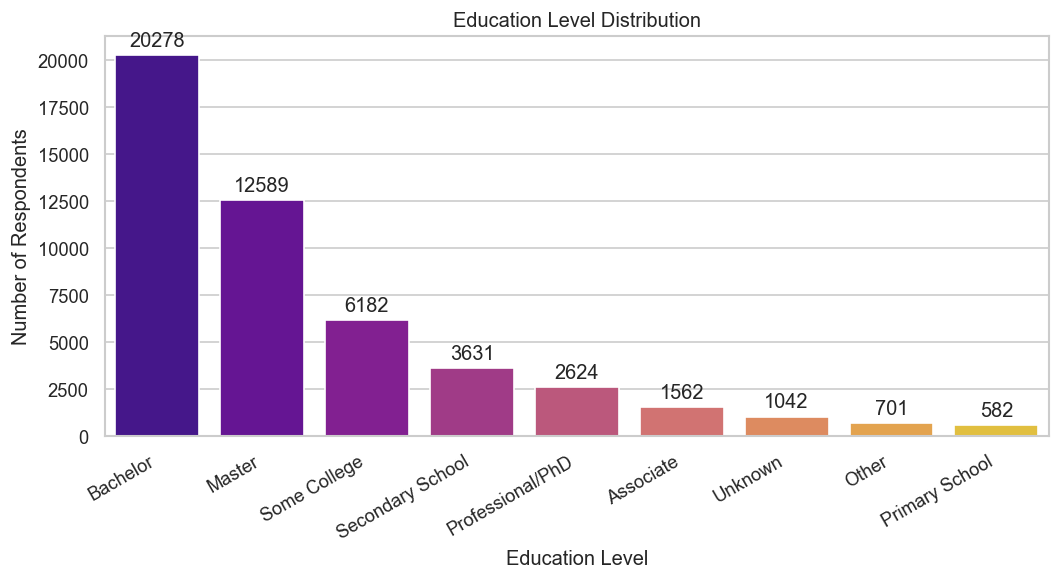

In [103]:
# Education level distribution (Vertical Bar Chart)
ed_distribution = (
    fact_df['EdLevelId'].value_counts().reset_index()
    .merge(education_df, on='EdLevelId')
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='EdLevelShort', y='count', data=ed_distribution, palette='plasma', hue='EdLevelShort', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Trình độ cử nhân (Bachelor) là phổ biến nhất với 20.278 người (khoảng 41.22% tổng số phản hồi).
* Trình độ thạc sĩ (Master) xếp thứ hai với 12.589 người (khoảng 25.59%).
* Các lập trình viên có nền tảng đại học chưa tốt nghiệp (Some College) chiếm 6.182 người (12.57%). Các số liệu này phản ánh đa số lập trình viên trong cộng đồng được đào tạo chính quy ở bậc đại học hoặc sau đại học.

<a id="23-remote-work-modes"></a>
### **2.3. Remote Work Modes**

**Câu hỏi:** Cơ cấu tỷ lệ các mô hình làm việc khác nhau của lập trình viên năm 2025 được phân bổ ra sao?

**Phương pháp:** Trực quan hóa hình thức làm việc trong bảng fact (loại bỏ giá trị Unknown) dưới dạng **Biểu đồ bánh donut (Donut Chart)** để làm nổi bật tỷ lệ đóng góp của từng mô hình làm việc.

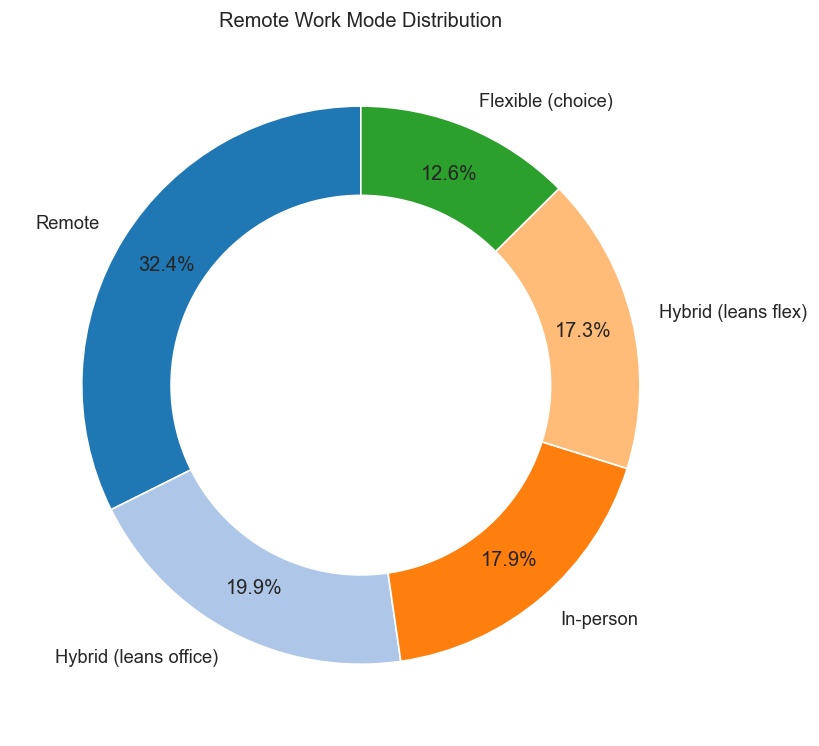

In [104]:
# Remote work distribution (excluding Unknown)
remote_dist = (
    fact_df[fact_df['RemoteWorkId'] != 6]['RemoteWorkId']
    .value_counts().reset_index()
    .merge(remote_df, on='RemoteWorkId')
)

# Shorten remote work mode descriptions uniformly
remote_map = {
    'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid (leans flex)',
    'Hybrid (some remote, leans heavy to in-person)': 'Hybrid (leans office)',
    'In-person': 'In-person',
    'Remote': 'Remote',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'Flexible (choice)',
    'Unknown': 'Unknown'
}
remote_dist['RemoteWorkShort'] = remote_dist['RemoteWork'].map(remote_map)

plt.figure(figsize=(7, 7))
colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c']
plt.pie(remote_dist['count'], labels=remote_dist['RemoteWorkShort'], autopct='%1.1f%%', 
        startangle=90, pctdistance=0.82, colors=colors)

# Draw inner circle to make it a donut
centre_circle = plt.Circle((0,0), 0.68, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Remote Work Mode Distribution')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Hình thức làm việc từ xa hoàn toàn (Remote) chiếm số lượng lớn nhất với 10.931 người (khoảng 32.36% số người đã xác định hình thức làm việc).
* Các mô hình làm việc kết hợp (Hybrid) cộng lại đạt hơn 12.500 người, cho thấy sự linh hoạt về địa điểm vẫn là ưu tiên hàng đầu của giới công nghệ.
* Hình thức làm việc hoàn toàn trực tiếp tại văn phòng (In-person) chỉ chiếm 6.042 người (12.28% tổng khảo sát), khẳng định làm việc từ xa hoặc kết hợp đã trở thành mô hình bền vững đối với ngành kỹ thuật phần mềm.

<a id="3-compensation--job-satisfaction"></a>
## **3. Compensation & Job Satisfaction**

**Mục tiêu:** Khảo sát mức thu nhập trung bình năm của lập trình viên theo hình thức làm việc, quy mô doanh nghiệp, và phân tích mối quan hệ giữa thu nhập và mức độ hài lòng trong công việc.

<a id="31-average-salary-by-remote-work-mode"></a>
### **3.1. Average Salary by Remote Work Mode**

**Câu hỏi:** Các hình thức làm việc khác nhau có sự chênh lệch lớn về mức thu nhập trung bình năm hay không?

**Phương pháp:** Tính thu nhập trung bình (`ConvertedCompYearlyCapped`) theo từng hình thức làm việc (loại bỏ Unknown) và vẽ biểu đồ cột đứng để so sánh trực quan theo chiều cao cột.

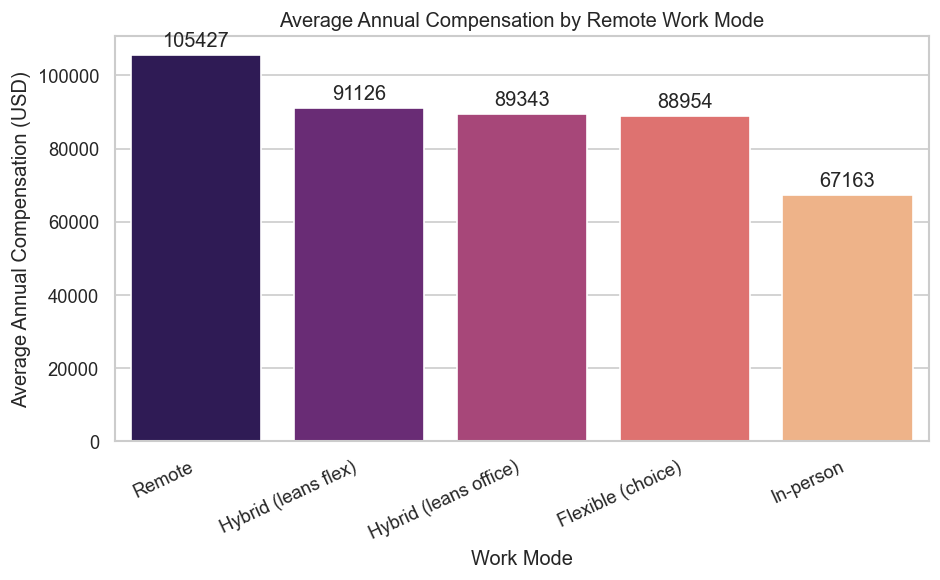

In [105]:
# Average salary by remote work mode
salary_remote = (
    fact_df[fact_df['RemoteWorkId'] != 6]
    .groupby('RemoteWorkId')['ConvertedCompYearlyCapped'].mean()
    .reset_index()
    .merge(remote_df, on='RemoteWorkId')
)
remote_map = {
    'Hybrid (some in-person, leans heavy to flexibility)': 'Hybrid (leans flex)',
    'Hybrid (some remote, leans heavy to in-person)': 'Hybrid (leans office)',
    'In-person': 'In-person',
    'Remote': 'Remote',
    'Your choice (very flexible, you can come in when you want or just as needed)': 'Flexible (choice)',
    'Unknown': 'Unknown'
}
salary_remote['RemoteWorkShort'] = salary_remote['RemoteWork'].map(remote_map)
salary_remote = salary_remote.sort_values('ConvertedCompYearlyCapped', ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x='RemoteWorkShort', y='ConvertedCompYearlyCapped', data=salary_remote, palette='magma', hue='RemoteWorkShort', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Average Annual Compensation by Remote Work Mode')
plt.xlabel('Work Mode')
plt.ylabel('Average Annual Compensation (USD)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Lập trình viên làm việc hoàn toàn từ xa (Remote) sở hữu mức thu nhập trung bình cao nhất với hơn 105.426 USD.
* Các mô hình làm việc kết hợp (Hybrid) và tự chọn (Your choice) dao động ở mức ổn định từ 88.000 USD đến 91.000 USD.
* Lập trình viên làm việc trực tiếp tại văn phòng (In-person) nhận mức thu nhập thấp nhất với trung bình 67.163 USD. Sự chênh lệch này cho thấy xu hướng các tập đoàn công nghệ lớn sẵn sàng chi trả mức lương cạnh tranh toàn cầu cho nhân sự làm việc từ xa chất lượng cao.

<a id="32-average-salary-by-organization-size"></a>
### **3.2. Average Salary by Organization Size**

**Câu hỏi:** Quy mô của doanh nghiệp ảnh hưởng như thế nào đến mức thu nhập trung bình của lập trình viên?

**Phương pháp:** Nhóm dữ liệu theo quy mô công ty, loại bỏ các nhóm không xác định và sắp xếp theo thứ tự phân cấp quy mô trước khi vẽ biểu đồ cột đứng.

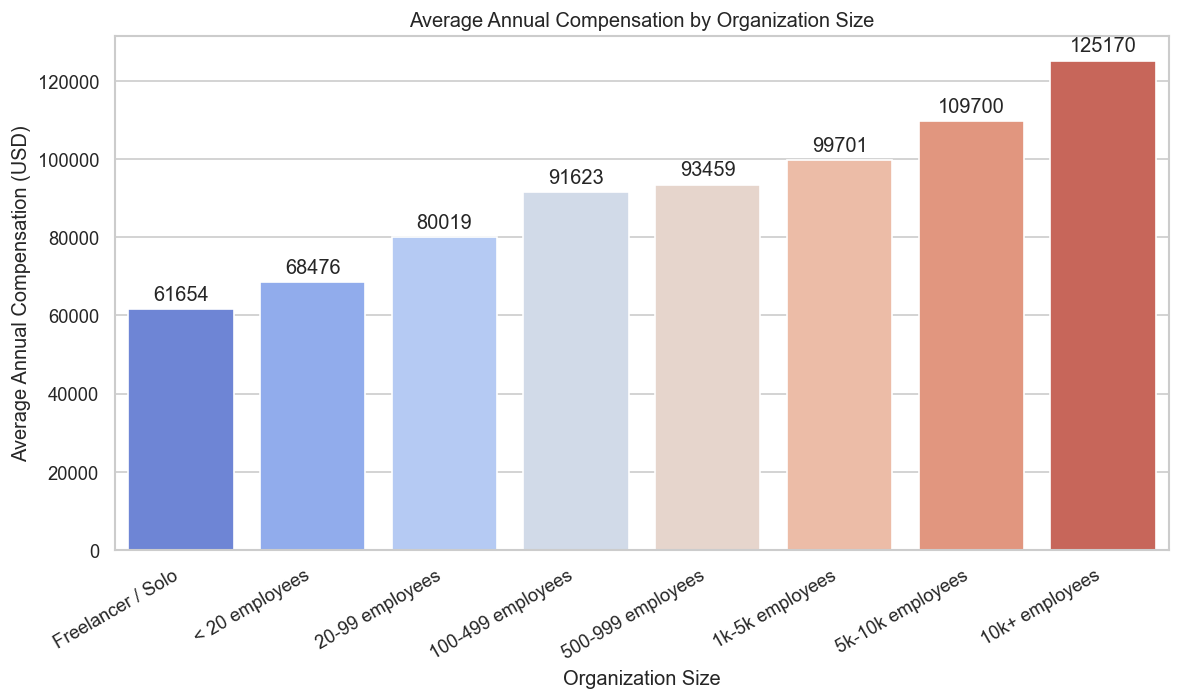

In [106]:
# Average salary by org size (excluding Unknown/I don't know)
invalid_orgs = [7, 10]
salary_org = (
    fact_df[~fact_df['OrgSizeId'].isin(invalid_orgs)]
    .groupby('OrgSizeId')['ConvertedCompYearlyCapped'].mean()
    .reset_index()
    .merge(org_size_df, on='OrgSizeId')
    .sort_values('OrgSizeSortOrder')
)

# Shorten organization size descriptions uniformly
org_map = {
    'Just me - I am a freelancer, sole proprietor, etc.': 'Freelancer / Solo',
    'Less than 20 employees': '< 20 employees',
    '20 to 99 employees': '20-99 employees',
    '100 to 499 employees': '100-499 employees',
    '500 to 999 employees': '500-999 employees',
    '1,000 to 4,999 employees': '1k-5k employees',
    '5,000 to 9,999 employees': '5k-10k employees',
    '10,000 or more employees': '10k+ employees',
    'I don\'t know': 'Don\'t know',
    'Unknown': 'Unknown'
}
salary_org['OrgSizeShort'] = salary_org['OrgSize'].map(org_map)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='OrgSizeShort', y='ConvertedCompYearlyCapped', data=salary_org, palette='coolwarm', hue='OrgSizeShort', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Average Annual Compensation by Organization Size')
plt.xlabel('Organization Size')
plt.ylabel('Average Annual Compensation (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Quy mô doanh nghiệp tỷ lệ thuận chặt chẽ với mức thu nhập. Các tập đoàn công nghệ lớn với quy mô trên 10.000 nhân viên chi trả mức lương trung bình cao nhất là 125.169 USD.
* Các doanh nghiệp tầm trung và lớn (từ 1.000 đến 9.999 nhân viên) trả mức thu nhập trung bình ổn định từ 99.000 USD đến 109.000 USD.
* Lập trình viên tự do (freelancer) và nhân sự tại các công ty khởi nghiệp siêu nhỏ (dưới 20 nhân viên) ghi nhận mức lương trung bình thấp nhất, dao động từ 61.000 USD đến 68.000 USD.

<a id="33-job-satisfaction-vs-salary"></a>
### **3.3. Job Satisfaction vs. Salary**

**Câu hỏi:** Phân phối thu nhập năm thay đổi thế nào đối với các mức độ hài lòng công việc khác nhau của lập trình viên?

**Phương pháp:** Sử dụng biểu đồ hộp (Box Plot) để trực quan hóa phân phối thu nhập năm (`ConvertedCompYearlyCapped`) ứng với từng mức độ hài lòng công việc (loại bỏ Unknown). Điều này cho phép chúng ta so sánh trung vị, các khoảng phân vị và quan sát độ phân cực rõ ràng hơn.

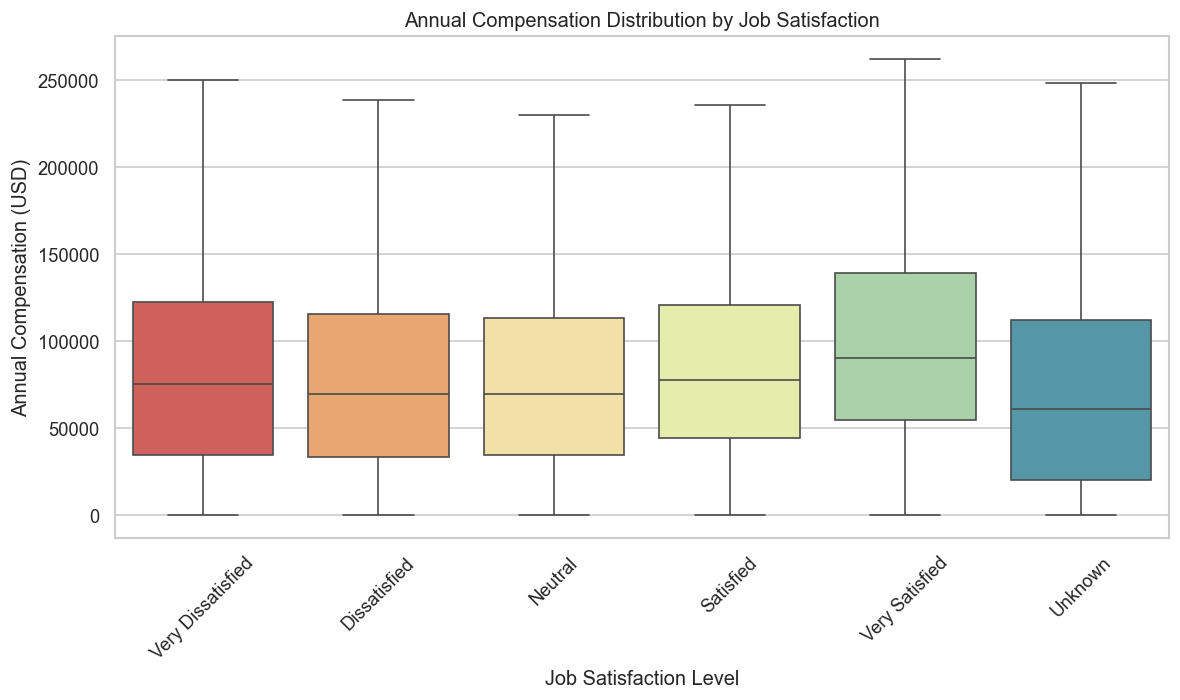

In [107]:
# Filter out Unknown job satisfaction
jobsat_filtered = fact_df[fact_df['JobSatId'] != 11].merge(job_sat_df, on='JobSatId')
jobsat_filtered = jobsat_filtered.sort_values('JobSatId')

plt.figure(figsize=(10, 6))
sns.boxplot(x='JobSatLabel', y='ConvertedCompYearlyCapped', data=jobsat_filtered, palette='Spectral', hue='JobSatLabel', legend=False, showfliers=False)
plt.title('Annual Compensation Distribution by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Annual Compensation (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét:**
* Biểu đồ hộp thể hiện rất rõ xu hướng tăng tiến của mức thu nhập theo sự gia tăng của độ hài lòng công việc. Hộp dữ liệu của nhóm rất hài lòng (Very Satisfied) nằm ở vị trí cao nhất với trung vị thu nhập vượt trội (khoảng 105.000 USD).
* Khoảng biến thiên thu nhập (IQR) của nhóm rất hài lòng cũng rộng hơn, cho thấy cơ hội đạt mức thu nhập cao hơn tập trung phần lớn ở nhóm nhân sự này.
* Ngược lại, nhóm không hài lòng (Dissatisfied và Very Dissatisfied) có trung vị thu nhập thấp hơn hẳn (dưới 88.000 USD) và dải phân bố hẹp hơn, củng cố kết luận rằng thu nhập thấp là một tác nhân rõ rệt đi kèm với sự chán nản công việc.

<a id="4-technology-ecosystem--popularity"></a>
## **4. Technology Ecosystem & Popularity**

**Mục tiêu:** Khảo sát hệ sinh thái công nghệ, xác định các ngôn ngữ lập trình được sử dụng phổ biến nhất hiện nay và xu hướng dịch chuyển công nghệ của lập trình viên trong tương lai.

<a id="41-most-popular-programming-languages"></a>
### **4.1. Most Popular Programming Languages**

**Câu hỏi:** Các ngôn ngữ lập trình hàng đầu có sự khác biệt thế nào giữa tỷ lệ sử dụng thực tế và mong muốn tiếp cận trong tương lai?

**Phương pháp:** Sử dụng biểu đồ quả tạ (Dumbbell Chart) nằm ngang để hiển thị sự chênh lệch và chuyển dịch giữa số lượng phản hồi 'Have Worked With' và 'Want To Work With' cho top 10 ngôn ngữ lập trình phổ biến nhất.

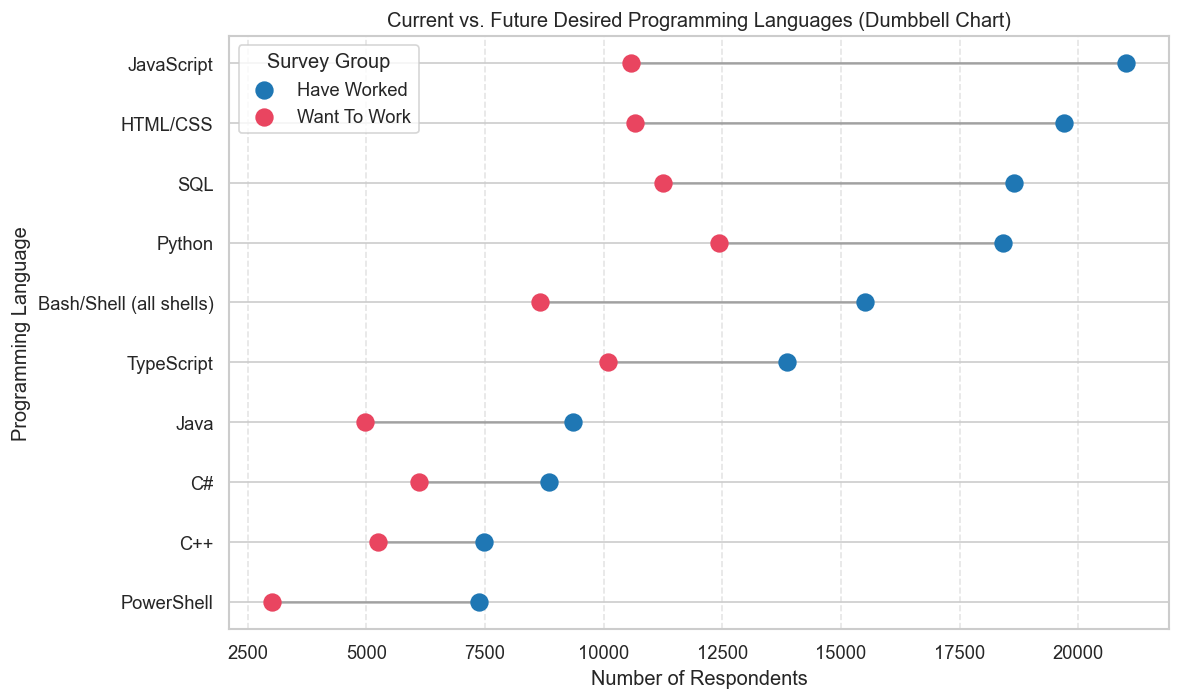

In [108]:
# Group technology by TechId and merge with dimension details
tech_counts = tech_bridge.groupby('TechId')['ResponseId'].count().reset_index(name='count')
tech_counts = tech_counts.merge(tech_dim, on='TechId')

# Get top 10 have languages
have_langs = (
    tech_counts[tech_counts['TechnologyGroup'] == 'Language - Have Worked With']
    .sort_values('count', ascending=False).head(10)
)
top_langs = have_langs['Technology'].tolist()

# Filter comparison data
compare_df = tech_counts[
    tech_counts['Technology'].isin(top_langs) &
    tech_counts['TechnologyGroup'].isin(['Language - Have Worked With', 'Language - Want To Work With'])
].copy()
compare_df['TechnologyGroup'] = compare_df['TechnologyGroup'].replace({
    'Language - Have Worked With': 'Have Worked',
    'Language - Want To Work With': 'Want To Work'
})

# Pivot to draw Dumbbell chart
pivot_compare = compare_df.pivot(index='Technology', columns='TechnologyGroup', values='count').reset_index()
pivot_compare = pivot_compare.sort_values('Have Worked', ascending=True)

plt.figure(figsize=(10, 6))
for idx, row in pivot_compare.iterrows():
    plt.plot([row['Have Worked'], row['Want To Work']], [row['Technology'], row['Technology']], color='grey', alpha=0.6, linewidth=1.5, zorder=1)

plt.scatter(pivot_compare['Have Worked'], pivot_compare['Technology'], color=PRIMARY_COLOR, s=100, label='Have Worked', zorder=2)
plt.scatter(pivot_compare['Want To Work'], pivot_compare['Technology'], color=ACCENT_COLOR, s=100, label='Want To Work', zorder=3)

plt.title('Current vs. Future Desired Programming Languages (Dumbbell Chart)')
plt.xlabel('Number of Respondents')
plt.ylabel('Programming Language')
plt.legend(title='Survey Group')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Nhận xét:**
* Biểu đồ quả tạ chỉ ra sự chuyển dịch lớn giữa thực tế và kỳ vọng. JavaScript (21.005 người đã dùng) và HTML/CSS (19.698 người đã dùng) dẫn đầu về sử dụng thực tế, nhưng nhu cầu sử dụng tương lai giảm rõ rệt (chỉ hơn 10.500 người muốn tiếp tục làm việc).
* Ngược lại, Python và SQL thể hiện sức hút vượt trội. Python dẫn đầu danh sách mong muốn sử dụng với 12.419 người lựa chọn, củng cố vị trí dẫn đầu của ngôn ngữ này trong kỷ nguyên trí tuệ nhân tạo.
* TypeScript và C# cho thấy mức độ trung thành cao từ nhà phát triển khi lượng mong muốn tiếp cận trong tương lai gần như tương đương với lượng sử dụng hiện tại.

<a id="42-top-web-frameworks"></a>
### **4.2. Top Web Frameworks**

**Câu hỏi:** Các framework web nào đang được lập trình viên sử dụng phổ biến nhất trong các dự án?

**Phương pháp:** Lọc nhóm Web Framework - Have Worked With từ bảng thống kê công nghệ và vẽ biểu đồ dạng kẹo mút (Lollipop Chart) nằm ngang của top 10 framework phổ biến nhất.

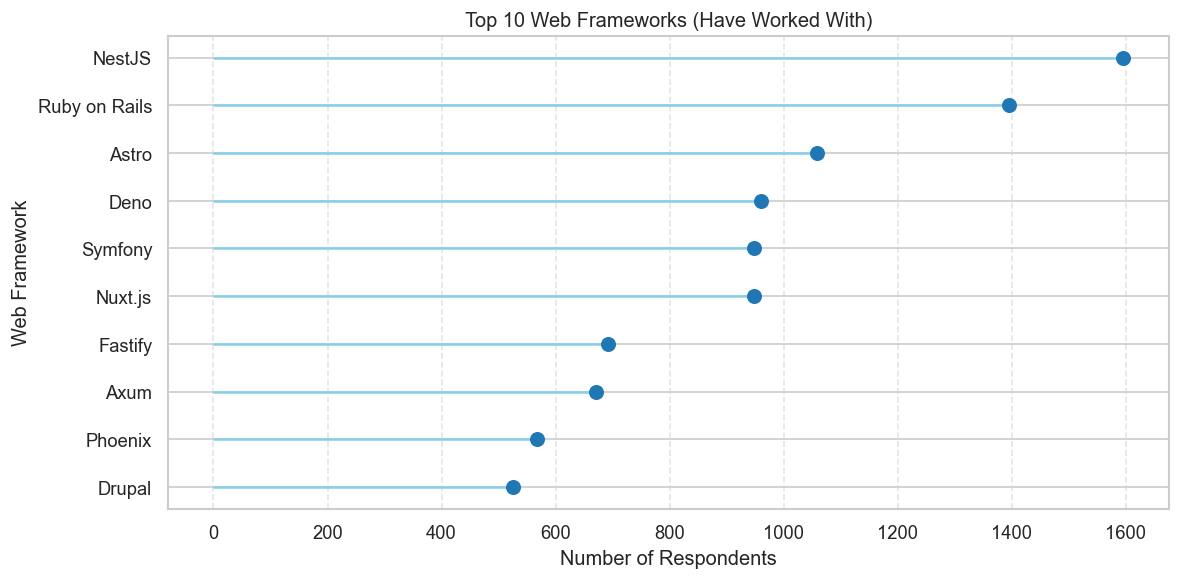

In [109]:
# Top 10 Web Frameworks (Have Worked With) - Lollipop Chart
web_frameworks = (
    tech_counts[tech_counts['TechnologyGroup'] == 'Web Framework - Have Worked With']
    .sort_values('count', ascending=True).head(10)
)

plt.figure(figsize=(10, 5))
plt.hlines(y=web_frameworks['Technology'], xmin=0, xmax=web_frameworks['count'], color='skyblue', linewidth=1.5)
plt.plot(web_frameworks['count'], web_frameworks['Technology'], 'o', color=PRIMARY_COLOR, markersize=8)
plt.title('Top 10 Web Frameworks (Have Worked With)')
plt.xlabel('Number of Respondents')
plt.ylabel('Web Framework')
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Nhận xét:**
* Dựa trên số liệu từ biểu đồ, NestJS (gần 1.600 người) và Ruby on Rails (gần 1.400 người) là hai công nghệ có số người dùng cao nhất trong nhóm này.
* Các công nghệ lâu đời hoặc thuộc thị trường ngách như Drupal (526 người) và Phoenix (568 người) chiếm vị trí cuối bảng với lượng người dùng ít ỏi.
* Sự góp mặt của một số framework tương đối mới và đang lên như Astro, Deno hay Fastify cho thấy dù chưa quá phổ biến, chúng vẫn duy trì được một cộng đồng sử dụng chuyên biệt và có tiềm năng phát triển.


<a id="5-ai-adoption-sentiment--trust"></a>
## **5. AI Adoption, Sentiment & Trust**

**Mục tiêu:** Khảo sát mức độ thâm nhập của các công cụ trí tuệ nhân tạo (AI) vào công việc lập trình, thái độ cảm nhận chung và mức độ tin tưởng thực tế của cộng đồng đối với các kết quả do AI tạo ra.

<a id="51-ai-tool-usage--developer-sentiment"></a>
### **5.1. AI Tool Usage & Developer Sentiment**

**Câu hỏi:** Tỷ lệ lập trình viên sử dụng công cụ AI và thái độ chung của họ đối với công nghệ này ra sao?

**Phương pháp:** Vẽ biểu đồ tròn thể hiện cơ cấu sử dụng công cụ AI (`AISelect`) và biểu đồ cột đứng thể hiện thái độ cảm nhận (`AISent`), loại bỏ các dữ liệu chưa xác định.

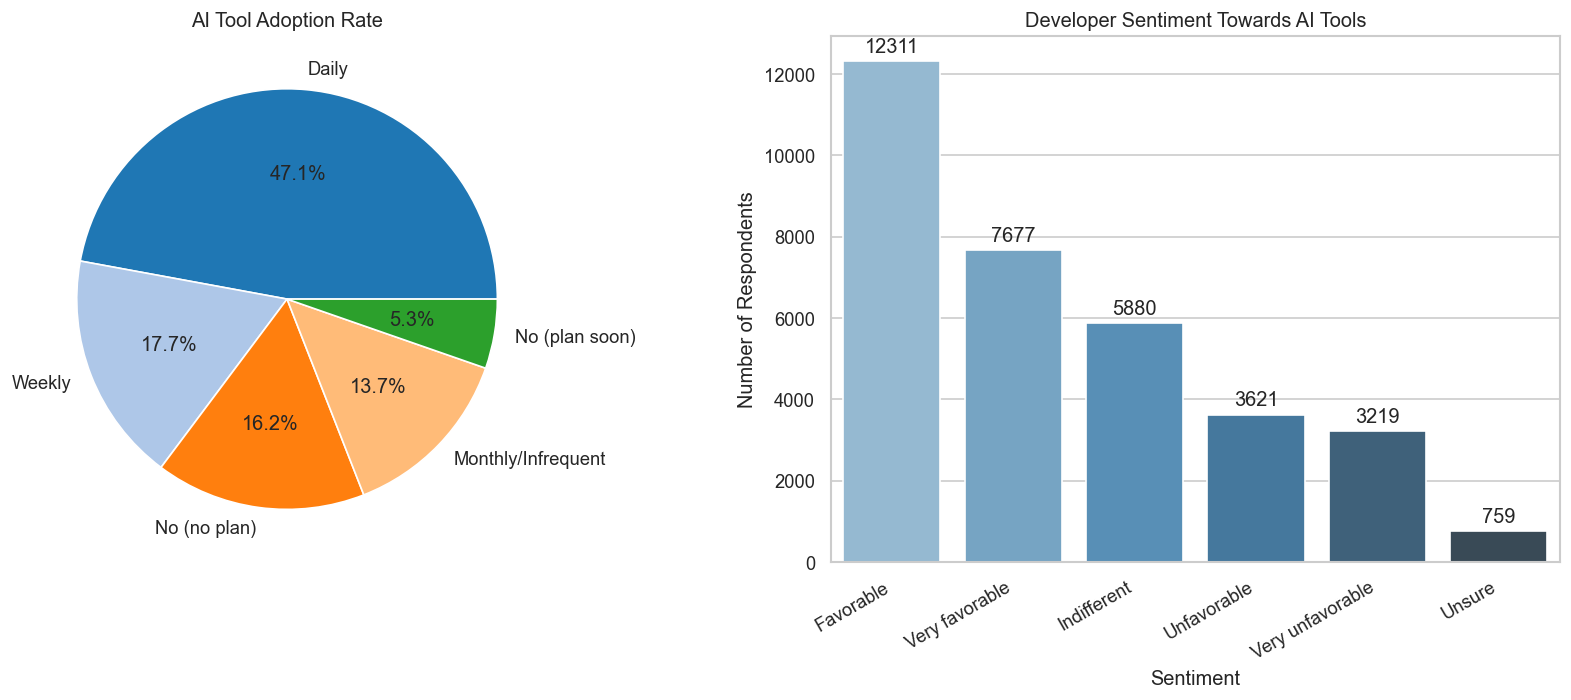

In [110]:
# AI Select (excluding Unknown)
ai_select_clean = (
    fact_df[fact_df['AISelectId'] != 6]['AISelectId']
    .value_counts().reset_index()
    .merge(ai_select_df, on='AISelectId')
)

# Shorten AI usage categories for neat pie labels
ai_sel_map = {
    'Yes, I use AI tools daily': 'Daily',
    'Yes, I use AI tools weekly': 'Weekly',
    'Yes, I use AI tools monthly or infrequently': 'Monthly/Infrequent',
    'No, and I don\'t plan to': 'No (no plan)',
    'No, but I plan to soon': 'No (plan soon)',
    'Unknown': 'Unknown'
}
ai_select_clean['AISelectShort'] = ai_select_clean['AISelect'].map(ai_sel_map)

# AI Sentiment (excluding Unknown)
ai_sent_clean = (
    fact_df[fact_df['AISentId'] != 7]['AISentId']
    .value_counts().reset_index()
    .merge(ai_sent_df, on='AISentId')
    .sort_values('count', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(ai_select_clean['count'], labels=ai_select_clean['AISelectShort'], autopct='%1.1f%%',
            colors=['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c'])
axes[0].set_title('AI Tool Adoption Rate')

sns.barplot(x='AISent', y='count', data=ai_sent_clean, ax=axes[1], palette='Blues_d', hue='AISent', legend=False)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3)
axes[1].set_title('Developer Sentiment Towards AI Tools')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Respondents')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

**Nhận xét:**
* Công cụ hỗ trợ AI đã được đón nhận rộng rãi trong quy trình làm việc thường nhật. 47.1% lập trình viên cho biết họ sử dụng công cụ AI hàng ngày và 17.7% sử dụng hàng tuần.
* Thái độ chung đối với AI mang thiên hướng ủng hộ rất tích cực. Nhóm ủng hộ (Favorable và Very favorable) chiếm đa số với tổng cộng hơn 20.000 phản hồi.
* Mặc dù vậy, số người phản hồi giữ thái độ thờ ơ hoặc không ủng hộ (Indifferent, Unfavorable, Very unfavorable), phản ánh rằng một bộ phận lập trình viên vẫn nghi ngờ giá trị thực tế mà AI mang lại.

<a id="52-ai-output-trust--developer-frustrations"></a>
### **5.2. AI Output Trust & Developer Frustrations**

**Câu hỏi:** Mức độ tin tưởng của lập trình viên vào tính chính xác của AI là bao nhiêu và những rào cản lớn nhất khi sử dụng là gì?

**Phương pháp:** Trực quan hóa mức độ tin cậy của AI (`AIAcc`) bằng biểu đồ cột dọc (loại bỏ nhóm chưa xác định) và xếp hạng top 4 vấn đề gây ức chế nhất bằng biểu đồ tròn (Pie Chart) từ bảng liên kết.

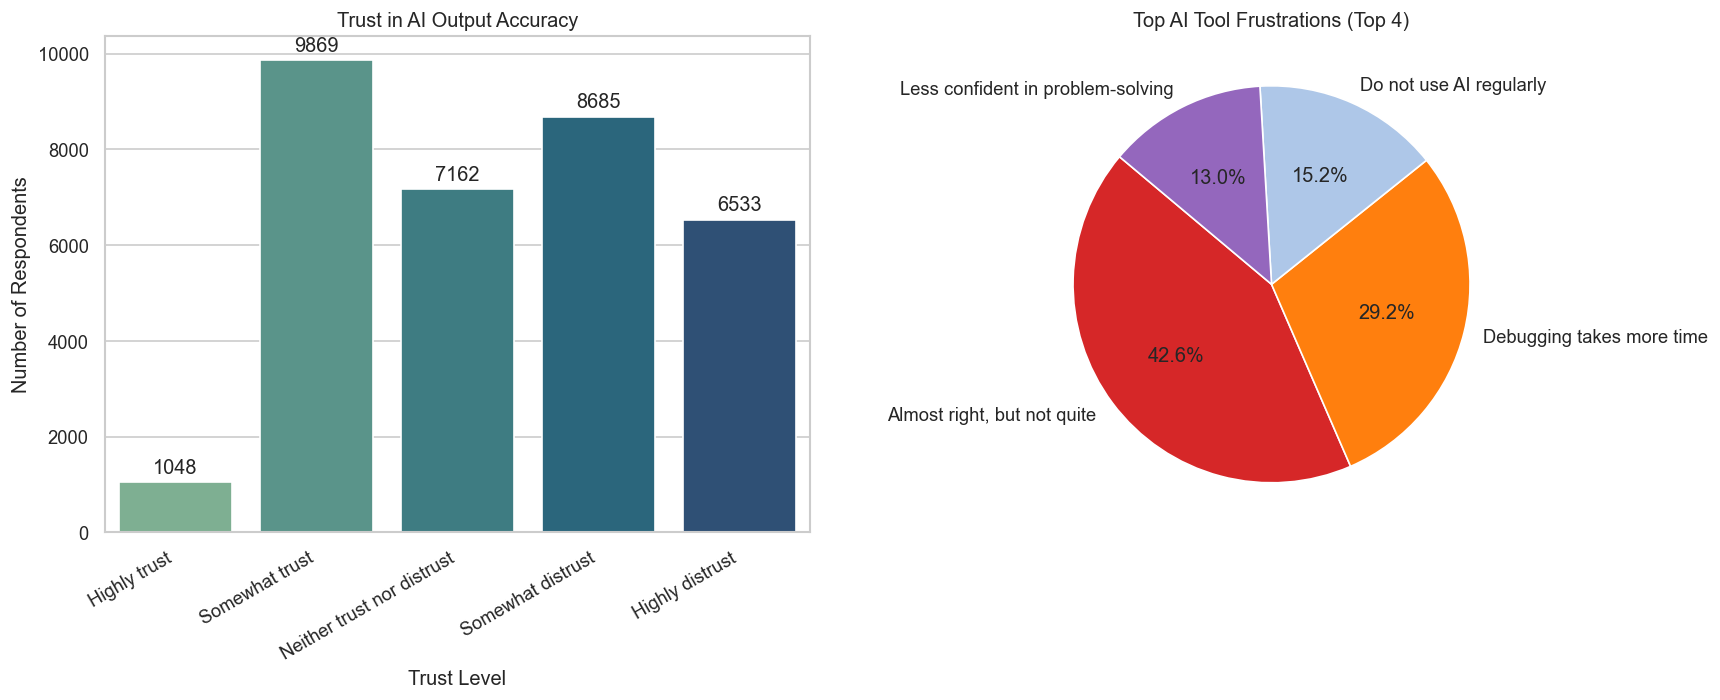

In [111]:
# AI Trust (excluding Unknown) (Vertical Bar Chart)
ai_trust_clean = (
    fact_df[fact_df['AIAccId'] != 6]['AIAccId']
    .value_counts().reset_index()
    .merge(ai_acc_df, on='AIAccId')
    .sort_values('TrustScore', ascending=False)
)

# Top AI Frustrations (using bridge and cleaning unicode characters)
frust_counts = ai_frust_bridge['FrustrationId'].value_counts().reset_index()
frust_counts = frust_counts.merge(ai_frust_dim, on='FrustrationId')
frust_counts['AIFrustrationClean'] = frust_counts['AIFrustration'].str.replace('’', "'", regex=False)

# Shorten frustration descriptions uniformly for plotting
frust_map = {
    'AI solutions that are almost right, but not quite': 'Almost right, but not quite',
    'Debugging AI-generated code is more time-consuming': 'Debugging takes more time',
    'It\'s hard to understand how or why the code works': 'Hard to understand how it works',
    'I\'ve become less confident in my own problem-solving': 'Less confident in problem-solving',
    'I don\'t use AI tools regularly': 'Do not use AI regularly',
    'I haven\'t encountered any problems': 'No problems encountered',
    'Other (write in):': 'Other'
}
frust_counts['AIFrustrationShort'] = frust_counts['AIFrustrationClean'].map(frust_map)

# Keep only the top 4 frustrations for a cleaner Pie Chart
frust_counts = frust_counts.sort_values('count', ascending=False).head(4)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x='AIAcc', y='count', data=ai_trust_clean, ax=axes[0], palette='crest', hue='AIAcc', legend=False)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', padding=3)
axes[0].set_title('Trust in AI Output Accuracy')
axes[0].set_xlabel('Trust Level')
axes[0].set_ylabel('Number of Respondents')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

axes[1].pie(frust_counts['count'], labels=frust_counts['AIFrustrationShort'], autopct='%1.1f%%',
            startangle=140, colors=['#d62728', '#ff7f0e', '#aec7e8', '#9467bd'])
axes[1].set_title('Top AI Tool Frustrations (Top 4)')

plt.tight_layout()
plt.show()

**Nhận xét:**
* Tính hoài nghi đối với kết quả đầu ra của AI vẫn hiện hữu mạnh mẽ. Số lượng người lựa chọn tin tưởng dè chừng (Somewhat trust đạt 9.869 người) hoặc nghi ngờ (Somewhat distrust đạt 8.685 người) chiếm tỷ số áp đảo, trong khi tỷ lệ tin tưởng tuyệt đối (Highly trust) chỉ đạt 1.048 người.
* Rào cản gây ức chế lớn nhất là việc AI đưa ra giải pháp trông có vẻ đúng nhưng thực tế lại sai (AI solutions that are almost right, but not quite) với 20.806 lượt bình chọn (42.3%).
* Khó khăn lớn thứ hai là việc debug và tìm lỗi trong các đoạn mã do AI tạo ra làm mất nhiều thời gian hơn cả tự viết (28.99% lượt chọn), cho thấy AI hiện tại mới chỉ giải quyết tốt các bài toán boilerplate đơn giản.

<a id="53-when-do-developers-prefer-humans"></a>
### **5.3. When do Developers Prefer Humans?**

**Câu hỏi:** Trong những tình huống nào lập trình viên vẫn muốn tìm đến sự hỗ trợ từ con người thay vì tin tưởng công cụ AI?

**Phương pháp:** Thống kê tần suất lựa chọn lý do từ bảng liên kết hỗ trợ con người, kết nối với bảng chiều lý do và vẽ biểu đồ cột ngang xếp hạng.

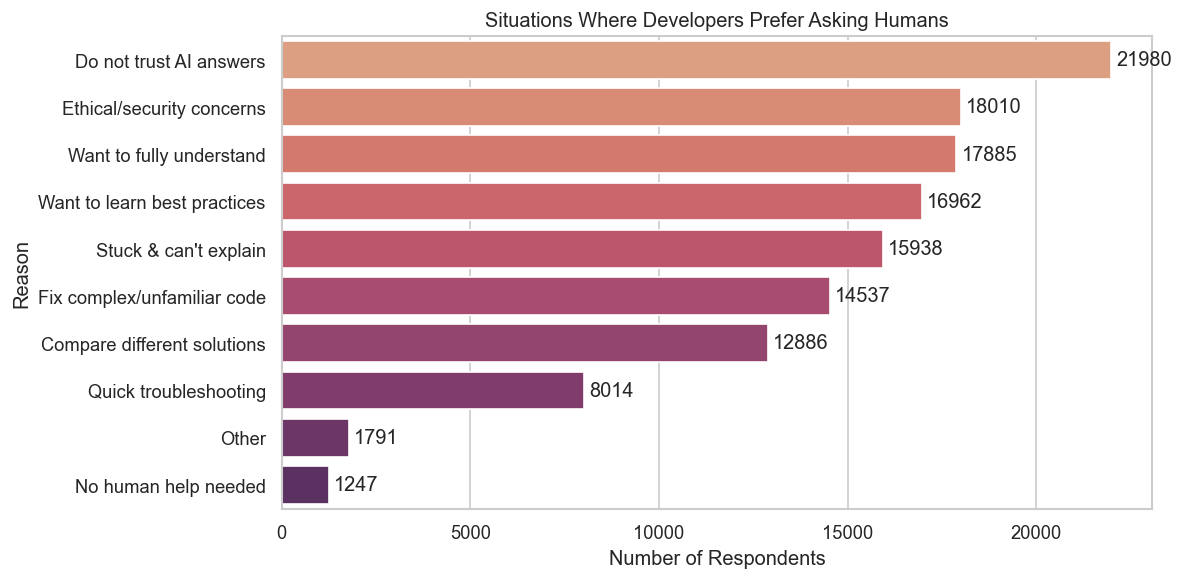

In [112]:
# Top reasons to ask humans instead of AI
human_counts = ai_human_bridge['HumanReasonId'].value_counts().reset_index()
human_counts = human_counts.merge(ai_human_dim, on='HumanReasonId')
human_counts['AIHumanReasonClean'] = human_counts['AIHumanReason'].str.replace('’', "'", regex=False)

# Shorten reasons uniformly for plotting
human_map = {
    'When I don\'t trust AI\'s answers': 'Do not trust AI answers',
    'When I have ethical or security concerns about code': 'Ethical/security concerns',
    'When I want to fully understand something': 'Want to fully understand',
    'When I want to learn best practices': 'Want to learn best practices',
    'When I\'m stuck and can\'t explain the problem': 'Stuck & can\'t explain',
    'When I need help fixing complex or unfamiliar code': 'Fix complex/unfamiliar code',
    'When I want to compare different solutions': 'Compare different solutions',
    'When I need quick help troubleshooting': 'Quick troubleshooting',
    'I don\'t think I\'ll need help from people anymore': 'No human help needed',
    'Other (please specify):': 'Other'
}
human_counts['AIHumanReasonShort'] = human_counts['AIHumanReasonClean'].map(human_map)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x='count', y='AIHumanReasonShort', data=human_counts, palette='flare', hue='AIHumanReasonShort', legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)
plt.title('Situations Where Developers Prefer Asking Humans')
plt.xlabel('Number of Respondents')
plt.ylabel('Reason')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Nguyên nhân hàng đầu khiến lập trình viên tìm đến sự trợ giúp từ đồng nghiệp hoặc cộng đồng con người là khi họ không tin tưởng vào câu trả lời của AI (21.980 lượt chọn).
* Các mối lo ngại về bảo mật dữ liệu và đạo đức công nghệ xếp vị trí thứ hai với 18.010 lượt chọn.
* Nhu cầu hiểu sâu bản chất vấn đề (Want to fully understand) với 17.885 lượt chọn và mong muốn học hỏi kinh nghiệm thực tế tốt nhất (best practices) đạt 16.962, nhấn mạnh rằng AI chỉ đóng vai trò hỗ trợ thực thi nhanh chứ chưa thể thay thế hoàn toàn vai trò định hướng của con người.

<a id="6-stack-overflow-community-dynamics"></a>
## **6. Stack Overflow Community Dynamics**

**Mục tiêu:** Khảo sát thói quen tương tác, tần suất sử dụng, mức độ gắn bó với cộng đồng Stack Overflow và đánh giá mức độ ảnh hưởng của AI đối với việc sử dụng nền tảng này.

<a id="61-so-account-ownership--visit-frequency"></a>
### **6.1. SO Account Ownership & Visit Frequency**

**Câu hỏi:** Tỷ lệ sở hữu tài khoản Stack Overflow và tần suất truy cập của lập trình viên hiện tại ra sao?

**Phương pháp:** Nạp thêm các cột thông tin Stack Overflow từ tệp khảo sát gốc, kết nối khớp với bảng fact qua ResponseId, vẽ biểu đồ tròn cho tài khoản sở hữu và biểu đồ cột đứng cho tần suất truy cập.

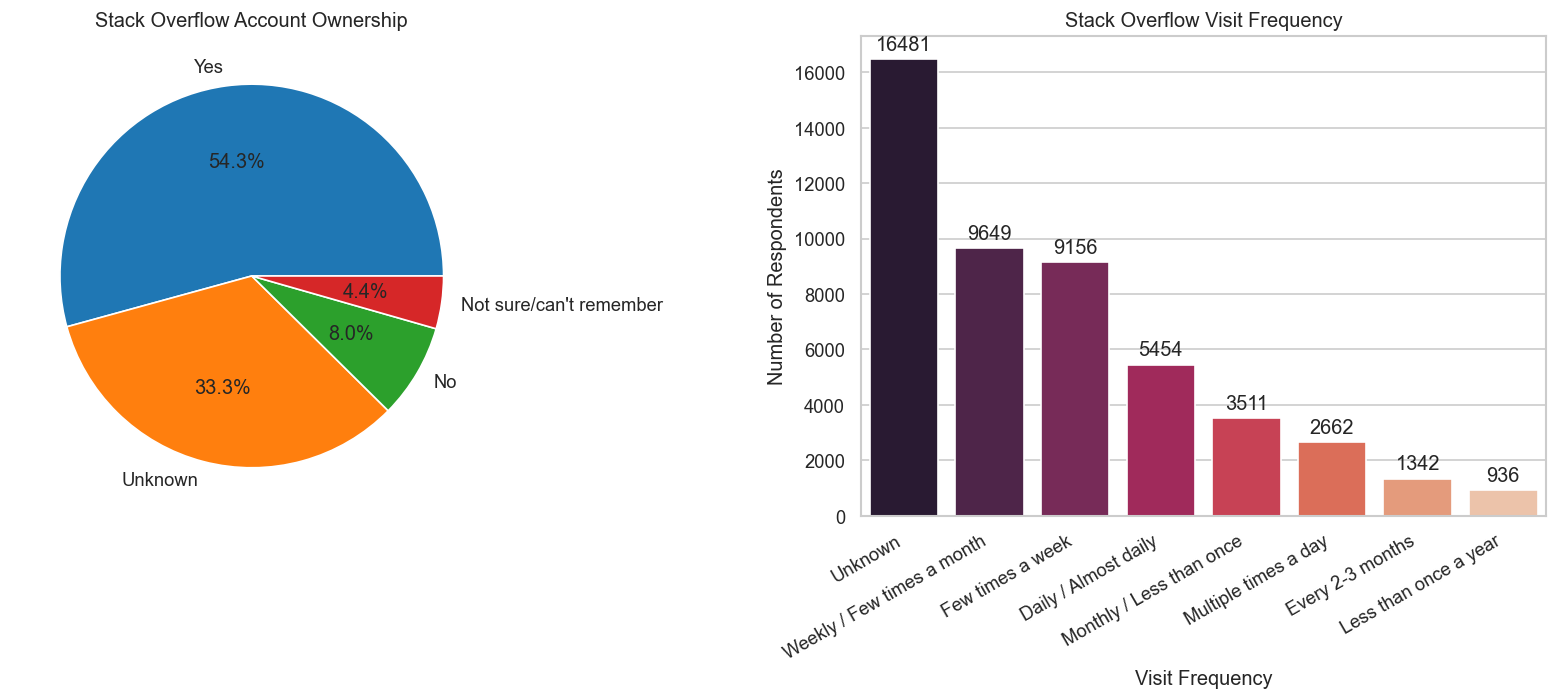

In [113]:
# Load Stack Overflow columns from raw data and merge
raw_so_df = pd.read_csv(RAW_DIR / 'survey_results_public.csv', 
                       usecols=['ResponseId', 'SOAccount', 'SOVisitFreq', 'SODuration', 'SOPartFreq', 'SOComm', 'SOFriction'],
                       encoding='utf-8-sig')
so_merged = fact_df[['ResponseId']].merge(raw_so_df, on='ResponseId')

# Clean values for plotting
so_account = so_merged['SOAccount'].fillna('Unknown').value_counts().reset_index()
so_visit = so_merged['SOVisitFreq'].fillna('Unknown').value_counts().reset_index()

# Shorten visit frequency labels
visit_map = {
    'A few times per month or weekly': 'Weekly / Few times a month',
    'A few times per week': 'Few times a week',
    'Daily or almost daily': 'Daily / Almost daily',
    'Less than once per month or monthly': 'Monthly / Less than once',
    'Multiple times per day': 'Multiple times a day',
    'Less than once every 2 - 3 months': 'Every 2-3 months',
    'Infrequently, less than once per year': 'Less than once a year',
    'Unknown': 'Unknown'
}
so_visit['SOVisitFreqShort'] = so_visit['SOVisitFreq'].map(visit_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(so_account['count'], labels=so_account['SOAccount'], autopct='%1.1f%%',
            colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Stack Overflow Account Ownership')

sns.barplot(x='SOVisitFreqShort', y='count', data=so_visit, ax=axes[1], palette='rocket', hue='SOVisitFreqShort', legend=False)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%d', padding=3)
axes[1].set_title('Stack Overflow Visit Frequency')
axes[1].set_xlabel('Visit Frequency')
axes[1].set_ylabel('Number of Respondents')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

**Nhận xét:**
* Stack Overflow vẫn duy trì vị thế cộng đồng lớn của mình với hơn 54.3% lập trình viên cho biết họ sở hữu tài khoản hoạt động.
* Tần suất truy cập phổ biến nhất là truy cập hàng tuần (16.481 chọn Weekly / Few times a month) và vài lần một tuần (9.156). Lượng truy cập hàng ngày (5.454) hoặc nhiều lần trong ngày (2.662) đóng góp hơn 16% tổng số phản hồi, chứng tỏ vai trò tham chiếu kỹ thuật của trang web vẫn rất ổn định.

<a id="62-so-usage-friction-from-ai"></a>
### **6.2. SO Usage Friction from AI**

**Câu hỏi:** Các công cụ AI có gây ra cản trở hay khó khăn gì cho việc sử dụng Stack Overflow của lập trình viên không?

**Phương pháp:** Thống kê tần suất gặp cản trở do AI (`SOFriction`) từ dữ liệu đã nạp (loại bỏ Unknown) và vẽ **Biểu đồ bánh (Pie Chart)** để làm nổi bật tỷ lệ các mức độ cản trở khác nhau.

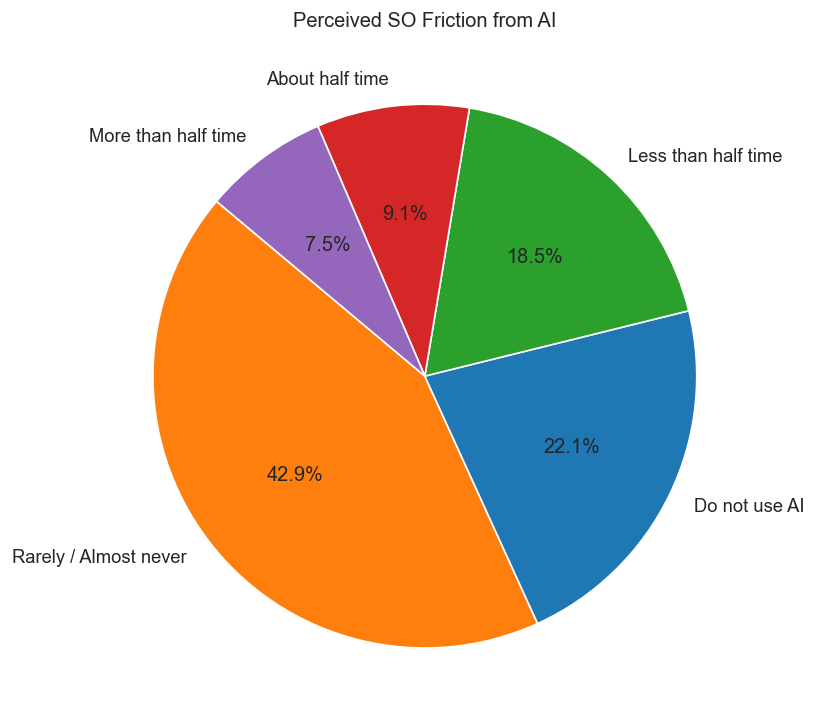

In [114]:
# AI Friction on Stack Overflow (excluding Unknown)
so_friction_clean = so_merged[so_merged['SOFriction'].notna() & (so_merged['SOFriction'] != 'Unknown')].copy()
so_friction_dist = so_friction_clean['SOFriction'].value_counts().reset_index()

# Shorten SO Friction labels for plotting
friction_map = {
    'Rarely, almost never': 'Rarely / Almost never',
    'I don\'t use AI or AI-enabled tools': 'Do not use AI',
    'Less than half of the time': 'Less than half time',
    'About half of the time': 'About half time',
    'More than half the time': 'More than half time'
}
so_friction_dist['SOFrictionShort'] = so_friction_dist['SOFriction'].map(friction_map)

plt.figure(figsize=(7, 7))
colors = ['#ff7f0e', '#1f77b4', '#2ca02c', '#d62728', '#9467bd']
plt.pie(so_friction_dist['count'], labels=so_friction_dist['SOFrictionShort'], autopct='%1.1f%%', 
        startangle=140, colors=colors)
plt.title('Perceived SO Friction from AI')
plt.tight_layout()
plt.show()

**Nhận xét:**
* Phần lớn lập trình viên cho biết họ hiếm khi hoặc gần như không bao giờ gặp cản trở khi sử dụng Stack Overflow song song với AI (42.9% chọn Rarely, almost never).
* Nhóm người dùng gặp cản trở dưới một nửa thời gian chiếm 18.5%, và nhóm gặp cản trở thường xuyên chiếm chưa đầy 10%. Điều này thể hiện rằng hai nguồn tài nguyên này đang bổ trợ cho nhau khá tốt thay vì loại trừ lẫn nhau trong công việc thực tế.

<a id="7-cross-dimension-correlations"></a>
## **7. Cross-Dimension Correlations**

**Mục tiêu:** Phân tích các mối tương quan định lượng giữa các biến số kinh nghiệm viết mã, số năm làm việc thực tế, số lượng công cụ công nghệ và mức thu nhập hàng năm.

<a id="71-quantitative-correlation-heatmap"></a>
### **7.1. Quantitative Correlation Heatmap**

**Câu hỏi:** Các biến số định lượng có liên hệ tuyến tính thế nào với nhau?

**Phương pháp:** Tính toán ma trận tương quan Pearson đối với các cột số chính trong bảng fact và trực quan hóa bằng bản đồ nhiệt có ghi chú số liệu.

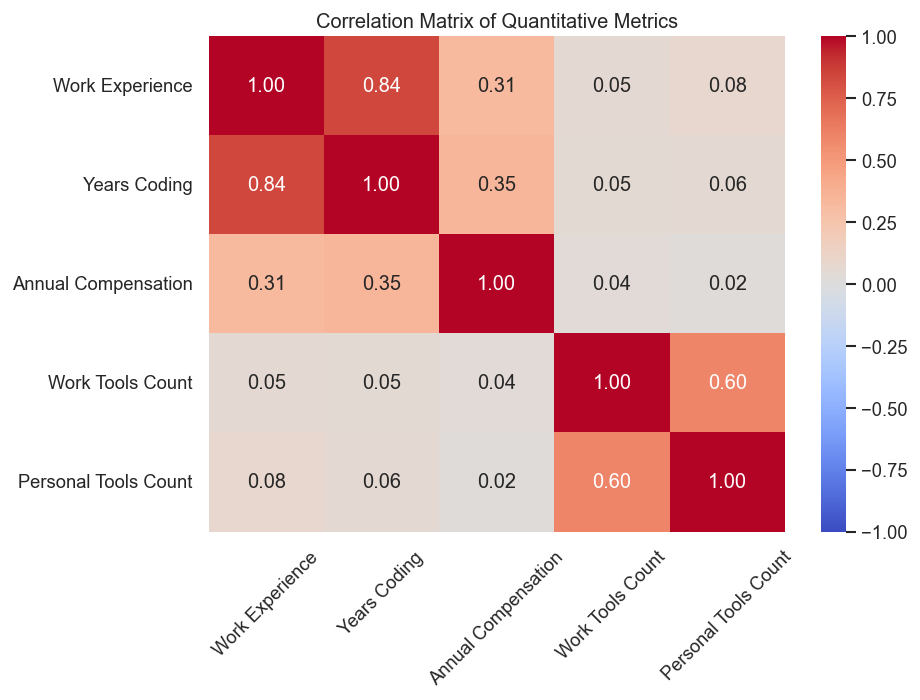

In [115]:
# Compute correlation matrix
corr_cols = ['WorkExp', 'YearsCodeNum', 'ConvertedCompYearlyCapped', 'ToolCountWork', 'ToolCountPersonal']
corr_matrix = fact_df[corr_cols].corr()

# Label index and columns clearly in English
english_cols = ['Work Experience', 'Years Coding', 'Annual Compensation', 'Work Tools Count', 'Personal Tools Count']
corr_matrix.columns = english_cols
corr_matrix.index = english_cols

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Quantitative Metrics')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Nhận xét:**
* Có mối tương quan tuyến tính rất chặt chẽ giữa số năm viết mã (YearsCodeNum) và số năm kinh nghiệm làm việc thực tế (WorkExp) với hệ số tương quan đạt 0.84.
* Thu nhập năm có mối tương quan thuận ở mức vừa phải với số năm viết mã (0.35) và số năm làm việc thực tế (0.31). Điều này cho thấy thâm niên nghề nghiệp vẫn đóng vai trò là một trong các cột mốc quyết định dải lương trong ngành phần mềm.
* Số lượng công cụ sử dụng tại nơi làm việc và cá nhân có tương quan thuận rõ rệt (0.60), cho thấy những người thích trải nghiệm nhiều công cụ trong công việc cũng có xu hướng khám phá nhiều công cụ cho dự án cá nhân của mình.

<a id="72-salary-trajectory-by-years-of-coding"></a>
### **7.2. Salary Trajectory by Years of Coding**

**Câu hỏi:** Mối liên hệ cụ thể giữa số năm kinh nghiệm viết mã và thu nhập thực tế của lập trình viên là gì?

**Phương pháp:** Vẽ biểu đồ mật độ lục giác kết hợp biểu đồ phân phối biên trên toàn bộ tập dữ liệu thay vì lấy mẫu ngẫu nhiên. Phương pháp này giải quyết được tình trạng đè lấp dữ liệu, giúp quan sát chính xác mật độ tập trung và xu hướng thu nhập theo số năm kinh nghiệm.

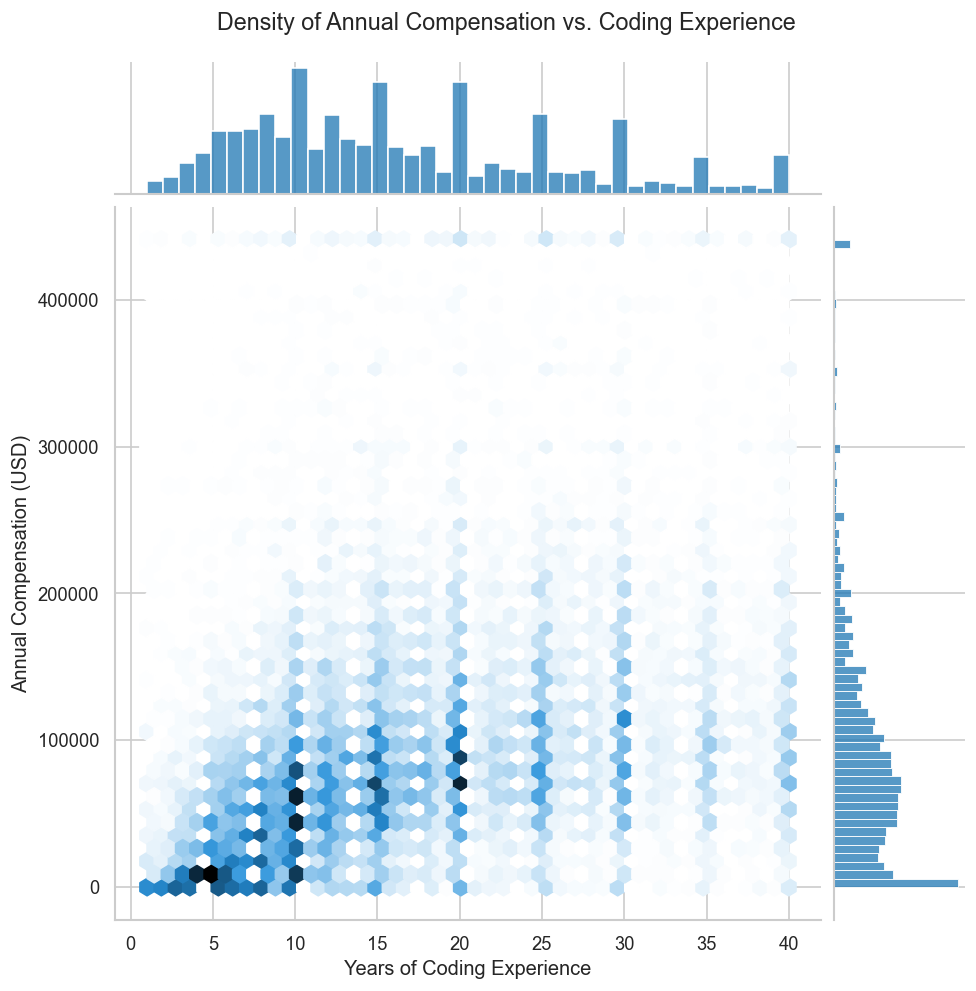

In [116]:
# Hexbin jointplot: Salary vs Coding Experience (filtered to YearsCodeNum <= 40)
filtered_fact = fact_df[(fact_df['YearsCodeNum'] <= 40) & (fact_df['ConvertedCompYearlyCapped'].notna())]

g = sns.jointplot(
    x='YearsCodeNum', 
    y='ConvertedCompYearlyCapped', 
    data=filtered_fact, 
    kind='hex', 
    color=PRIMARY_COLOR,
    height=8,
    space=0.1
)
g.fig.suptitle('Density of Annual Compensation vs. Coding Experience', y=1.03, fontsize=14)
g.set_axis_labels('Years of Coding Experience', 'Annual Compensation (USD)')
plt.show()

**Nhận xét:**
* Dựa trên phân tích, kinh nghiệm và thu nhập có mối tương quan thuận ở mức khá. Biểu đồ mật độ thể hiện rõ xu thế tăng tịnh tiến này: mức lương trung vị tăng mạnh từ ~16.700 USD (nhóm 0-5 năm) lên ~48.700 USD (6-10 năm) và chạm mức ~110.000 USD cho nhóm 26-30 năm kinh nghiệm.
* Đồ thị phân bố biên và các vùng lục giác đậm màu nhất chỉ ra rằng mật độ tập trung dày đặc nhất nằm ở nhóm lập trình viên có từ 2 đến 10 năm kinh nghiệm với mức thu nhập dưới 50.000 USD. Điều này phản ánh rõ cơ cấu nhân sự trẻ và nhóm thu nhập trung bình-thấp đang chiếm tỷ trọng lớn trong tập dữ liệu khảo sát.
* Mặc dù xu hướng chung là tăng, độ phân tán (mức độ trải dọc của các điểm lục giác) về thu nhập tại cùng một mốc kinh nghiệm là rất lớn. Việc nhiều người cùng có 10 năm kinh nghiệm nhưng thu nhập lại trải dài từ dưới 20.000 USD đến hơn 200.000 USD khẳng định rằng thâm niên viết mã chỉ là một yếu tố nền; những biến số khác như quốc gia làm việc, vai trò công việc hay quy mô tổ chức mới mang tính quyết định cuối cùng đến thu nhập thực tế.

<a id="8-key-findings--strategic-insights"></a>
## **8. Key Findings & Strategic Insights**

**Mục tiêu:** Tổng hợp các phát hiện then chốt rút ra từ nghiên cứu phân tích dữ liệu khảo sát lập trình viên năm 2025.

*Sự phát triển mạnh mẽ của trí tuệ nhân tạo:*
* Việc tích hợp AI vào quy trình làm việc đã trở thành chuẩn mực mới với gần một nửa số lập trình viên sử dụng hàng ngày.
* Tuy nhiên, cộng đồng vẫn giữ thái độ hoài nghi lành mạnh đối với tính chính xác của AI do các lỗi sai tinh vi gây mất nhiều thời gian debug.
* Sự hỗ trợ từ cộng đồng con người vẫn giữ vai trò then chốt khi giải quyết các bài toán phức tạp, bảo mật dữ liệu, và học hỏi kinh nghiệm tốt nhất.
* Quỹ đạo thu nhập và sự hài lòng nghề nghiệp liên quan chặt chẽ với quy mô doanh nghiệp và thâm niên làm việc, trong đó hình thức làm việc từ xa tiếp tục mang lại lợi thế thu nhập cao nhất cho nhân sự công nghệ.